<a href="https://colab.research.google.com/github/eudoalah-prog/Ass-2/blob/main/Ass_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.1

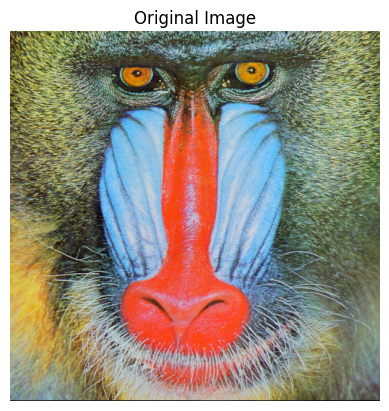

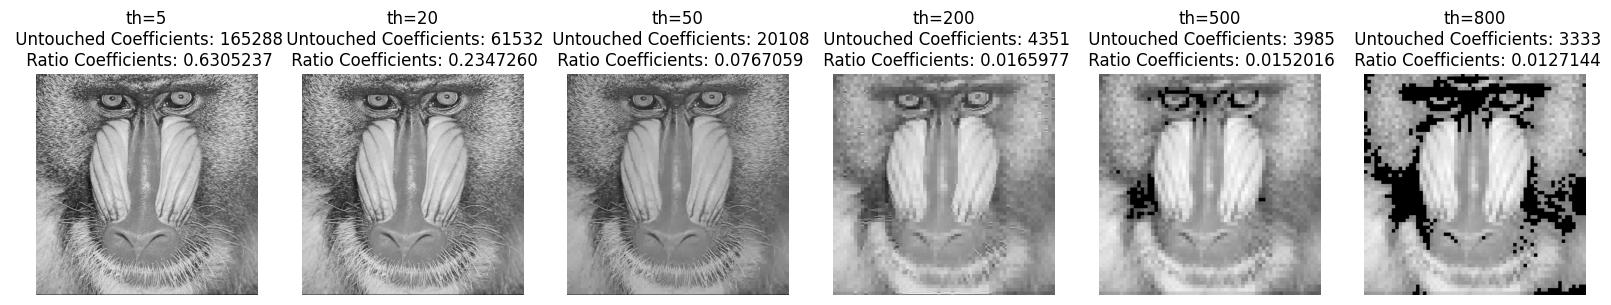

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct
from scipy.fftpack import idct

def prepare_image(path, space='YCrCb'):
    img_bgr = cv2.imread(path)
    if space.upper() == 'YCRCB':
        img_converted = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    elif space.upper() == 'LAB':
        img_converted = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    else:
        img_converted = img_bgr

    y_channel = img_converted[:, :, 0].astype(float)

    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    return img_converted, y_channel

# DCT
def apply_dct8x8(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

# IDCT
def apply_idct8x8(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# Apply DCT, THRESHOLDING AND IDCT
def apply_dct_and_idct_to_image(y_channel, thereshold_value):
    h, w = y_channel.shape

    # print(h)
    # Padding
    pad_h = (8 - (h % 8)) % 8
    pad_w = (8 - (w % 8)) % 8
    new_h = h + pad_h
    new_w = w + pad_w
    padded = np.zeros((new_h, new_w))
    padded[:h, :w] = y_channel

    final = np.zeros((new_h, new_w),dtype=float)
    count = 0

    for i in range (0, new_h, 8):
        for j in range(0,new_w, 8):
            block = padded[i:i+8, j:j+8]
            # DCT
            dct_block = apply_dct8x8(block)

            # Thereshold
            threshold_block, threshold_count = threshold(dct_block, thereshold_value)
            count += threshold_count

            # IDCT
            idct_block = apply_idct8x8(threshold_block)

            final[i:i+8, j:j+8] = idct_block

    # Removing Padding
    final = final[:h, :w]

    total = ((new_h // 8) * (new_w // 8)) * 64


    return final, count, total

def threshold(block, th_value):
    aux = np.zeros_like(block)
    count = 0

    h,w = block.shape

    for i in range (h):
        for j in range (w):
            if(abs(block[i,j]) >= th_value):
                aux[i,j] = block[i,j]
                count += 1
            else:
                aux[i,j] = 0

    return aux, count

converted, y_channel = prepare_image('./images/baboon.png', 'YCrCb')

plt.figure(figsize=(20, 6))  # largura x altura

threshold_v = [5, 20, 50, 200, 500, 800]

for idx, th in enumerate(threshold_v):
    image_mod, retained, total = apply_dct_and_idct_to_image(y_channel, th)
    plt.subplot(1, len(threshold_v), idx + 1)
    plt.imshow(image_mod, cmap='gray')
    plt.title(f"th={th}\n Untouched Coefficients: {retained}\n Ratio Coefficients: {(retained / total):.7f}")
    plt.axis('off')

# plt.suptitle("")
plt.show()




In this exercise, we compress an image using DCT and then reconstruct it to evaluate the loss in quality.

Overall steps
1. Read the image
2. Convert it to a color space with luminance (Y + color)
3. Divide the image into 8×8 blocks
4. Apply DCT (compression in the frequency domain)
5. Remove small coefficients (thresholding)
6. Apply IDCT
7. Reconstruct everything and display the final image

We start by reading an RGB image, displaying it, and converting it to a color space such as YCrCb or L*a*b. This is done to separate luminance (brightness) from chrominance (color), since compression is mainly applied to the luminance component. This works because the human eye is much more sensitive to brightness than to color, allowing us to compress color more aggressively.

Next, we apply the DCT to each 8×8 block. The DCT transforms the image from the spatial domain (pixels) to the frequency domain.

After that, we apply a threshold to remove coefficients with values smaller than a chosen threshold, reducing the amount of information and achieving compression. At this stage, each output is an 8×8 matrix where many values become zero. The higher the threshold, the greater the compression and the lower the quality.

Finally, we apply the IDCT, which performs the inverse transform, reconstructing the image from the processed blocks.

**1.2 Resultls and Subjective Evaluation (MOS)**

In this experiment, we tested the jpeg compression pipeline using the Discrete Cosine Transform (DCT) on the "baboon.png" image. By increasing the thresholld(th), we manually controeld how many frequency coefficients were retained. The process involved dividing the luminance (Y) channel into 8x8 blocks, applying padding where necessary and executing the fulll DCT - Threshold - IDCT chain.

**Visual Results and Retained Coefficients.**

The figures generated in the script abover illustrate the trade off between the threshold value and the "recovered" signal quality.

| Threshold ($th$) | Retained Coefficients | MOS Score (1-5) | Subjective Observation |
| :--- | :--- | :--- | :--- |
| **5** | High | **5** | Excellent; virtually indistinguishable from the original. |
| **20** | Medium-High | **4** | Good; very slight softening of the hair texture. |
| **50** | Medium | **4** | Good; minor artifacts in high-contrast areas. |
| **200** | Low | **3** | Fair; visible blocking artifacts (8x8 squares appear). |
| **500** | Very Low | **2** | Poor; significant loss of detail and heavy blockiness. |
| **800** | Minimal | **1** | Bad; the image structure is mostly lost. |



**Efficiency Anallysis by Image Content**

The efficiency of this compression method depends heavily on the spatial frequency of the source image.

*   **Smooth image (low detail):** These are highly efficient in areas llike a celar sky, the DCT concentrates almost all energy into the DC coefficient (the top elft of the 8x8 block). we can use a high threshold and still get a MOS of 4 or 5 because there is very littlle detail to lose.



*  **Moderatey detaield image:** These show a standard compression curve. We retain a balanced number of coefficients to keep shapes while discarding noise.



*   **Highly detailed images:** These are the lelast efficient because the image contians many high frequency signals, the DCT spreads energy across many AC coefficients. Increasing the threshold causes immediate blocking artifacts, as the details that define the texture are discarded, elaving onlly the as the detaisl that define the texture are discarded, leaving only the average color of each 8x8 bock.

**Conclusion**

The experiment confirms that JPEG pipeline is highly effective for data reduction, but its success relies on the Threshold(th) value. At higher thresholdl, we see a "quantization" effect where the human eye perceives the boundaries of the 8x8 blocks, signicantly owering the mean Opinion Score (MOS).

# 2.1

In [51]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

def get_Q50():
    return np.array([
        [16,11,10,16,24,40,51,61],
        [12,12,14,19,26,58,60,55],
        [14,13,16,24,40,57,69,56],
        [14,17,22,29,51,87,80,62],
        [18,22,37,56,68,109,103,77],
        [24,35,55,64,81,104,113,92],
        [49,64,78,87,103,121,120,101],
        [72,92,95,98,112,100,103,99]
    ], 
    dtype=float)


def compute_quantisation_matrix(F):
    F = max(1, min(100, F))
    Q50 = get_Q50()
    if F < 50:
        S = 5000 / F
    else:
        S = 200 - 2 * F
    QF = np.floor((S * Q50 + 50) / 100.0)
    QF = np.clip(QF, 1, 255)
    return QF


def quantise_block(dct_block, quality_factor):
    QF = compute_quantisation_matrix(quality_factor)
    quantised = np.sign(dct_block) * np.floor(np.abs(dct_block) / QF)
    return quantised.astype(int), QF


def inverse_quantise_block(quantised_block, QF):
    return quantised_block * QF

def evaluate_quality(original, reconstructed):
    reconstructed = np.clip(reconstructed, 0, 255)
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        psnr_value = float('inf')
    else:
        psnr_value = 10 * np.log10((255 ** 2) / mse)
    ssim_value = ssim(original, reconstructed, data_range=255)
    return psnr_value, ssim_value


After applying the DCT, we obtain an 8×8 matrix of coefficients. The issue is that these values are still relatively large and take up a lot of space, so the goal is to turn many of them into zeros in order to achieve compression.

In this step, we also introduce the concept of a Quality Factor, which works like a quality control knob. A high value results in minimal division and better image quality, while a low value increases division, produces more zeros, and therefore leads to higher compression.

We start with a function get_Q50(), which returns the base JPEG quantization matrix and serves as the standard compression reference. Then, compute_quantisation_matrix(F) adjusts this matrix according to the chosen quality factor.

Moving on to quantization, each value is divided and rounded (typically toward zero while preserving the sign). This means small values become zero, while larger values are reduced in magnitude—this is where the actual compression happens. In inverse quantization, we attempt to reconstruct the original values, but since information has already been lost, we can only approximate them.

In this section, we also evaluate image quality using two metrics: PSNR and SSIM. PSNR measures the error between images—the higher the value, the better the quality. SSIM measures how similar the images appear, with values closer to 1 indicating higher similarity.

Overall, this step corresponds to the JPEG stage where DCT coefficients are quantized to introduce zeros and compress the image, followed by an evaluation of how much the image quality has been degraded.

# 2.2

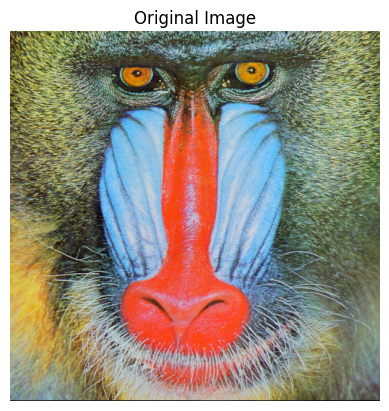

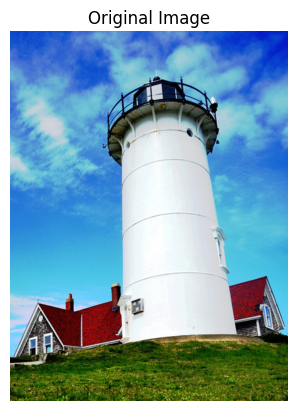

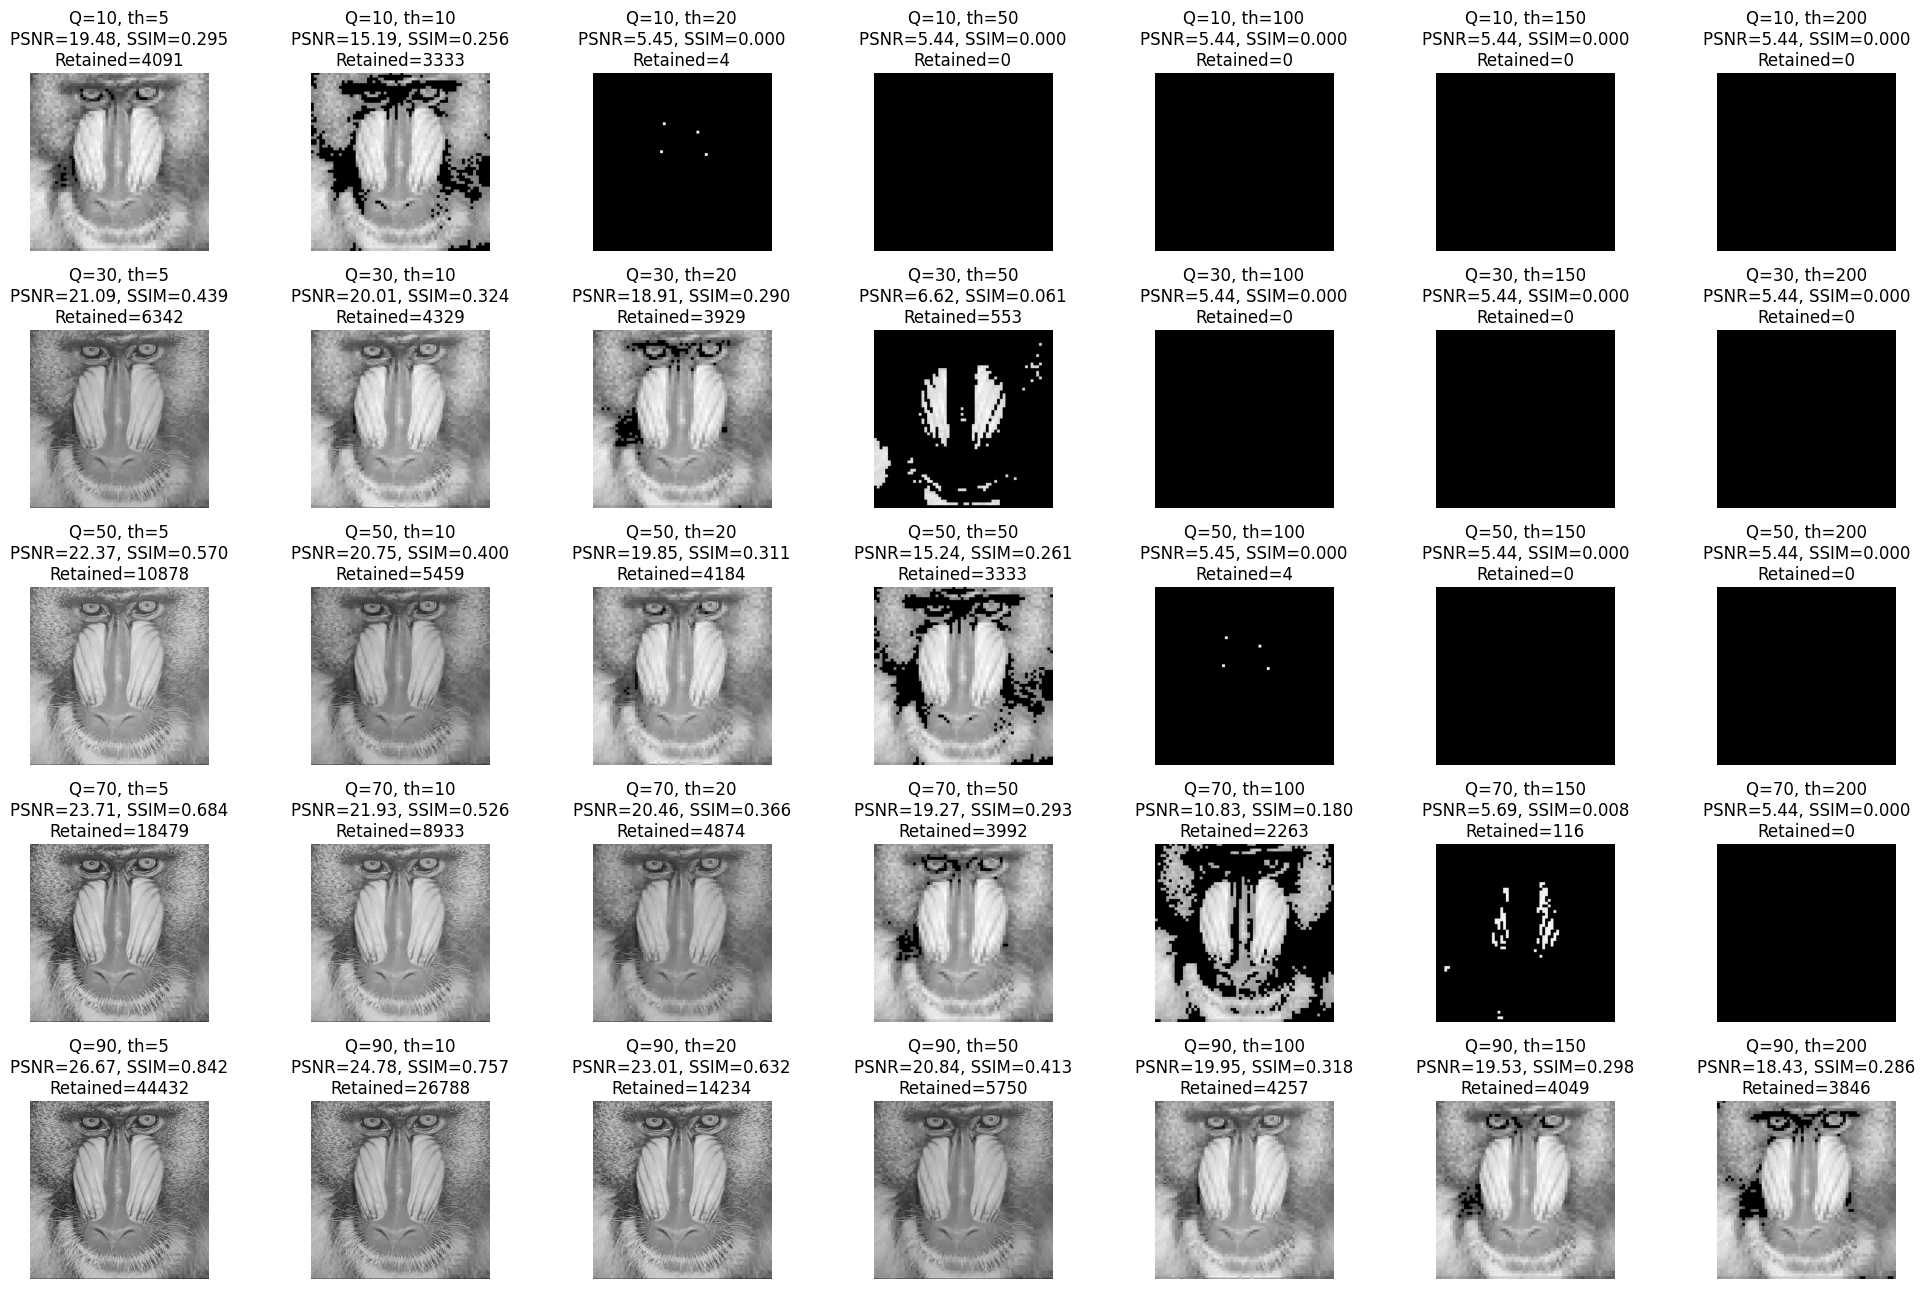

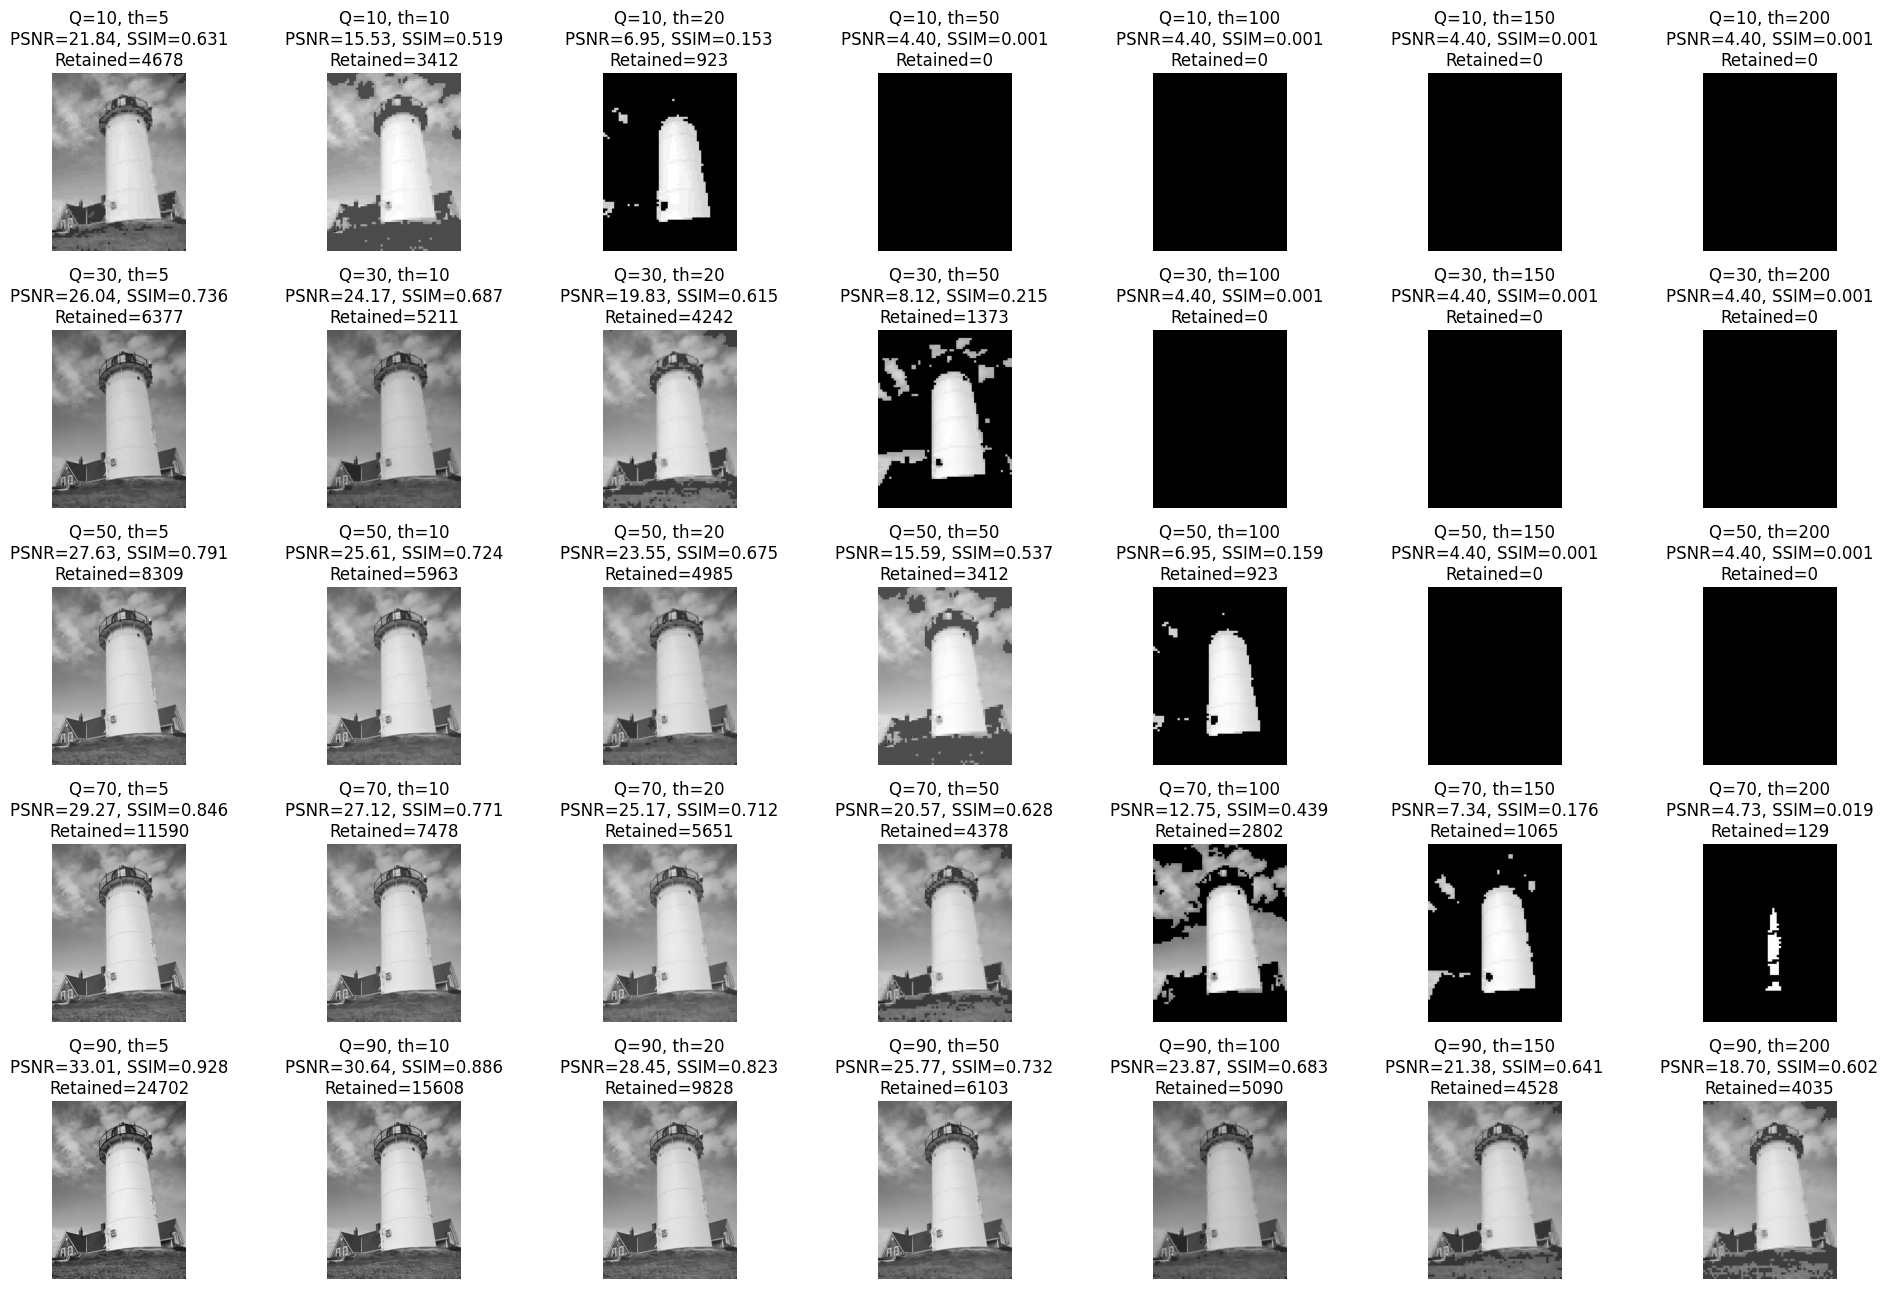

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def jpeg_compression(y_channel, quality_factor, threshold_value):
    h, w = y_channel.shape

    # Padding
    pad_h = (8 - (h % 8)) % 8
    pad_w = (8 - (w % 8)) % 8
    new_h = h + pad_h
    new_w = w + pad_w
    padded = np.zeros((new_h, new_w))
    padded[:h, :w] = y_channel

    final = np.zeros((new_h, new_w), dtype=float)
    total_retained = 0

    for i in range(0, new_h, 8):
        for j in range(0, new_w, 8):

            block = padded[i:i+8, j:j+8]

            # 1. DCT
            dct_block = apply_dct8x8(block)

            # 2. Quantização
            quant_block, QF = quantise_block(dct_block, quality_factor)

            # 3. Threshold
            thresh_block, retained = threshold(quant_block, threshold_value)
            total_retained += retained

            # 4. Inverse Quantização
            inv_quant = inverse_quantise_block(thresh_block, QF)

            # 5. IDCT
            idct_block = apply_idct8x8(inv_quant)

            final[i:i+8, j:j+8] = idct_block

    # Remove padding
    final = final[:h, :w]

    total_final = ((new_h // 8) * (new_w // 8)) * 64

    return final, total_retained, total_final


converted, y_channel = prepare_image('./images/baboon.png', 'YCrCb')
converted, y_channel1 = prepare_image('./images/lighthouse.png', 'YCrCb')

quality_factors = [10, 30, 50, 70, 90]
threshold_values = [5, 10, 20, 50, 100, 150, 200]

plt.figure(figsize=(20, 13))
idx = 1
for q in quality_factors:
    for th in threshold_values:
        image_mod, retained, total_final = jpeg_compression(y_channel, q, th)
        psnr_val, ssim_val = evaluate_quality(y_channel, image_mod)
        plt.subplot(len(quality_factors), len(threshold_values), idx)
        plt.imshow(image_mod, cmap='gray')
        plt.title(f"Q={q}, th={th}\nPSNR={psnr_val:.2f}, SSIM={ssim_val:.3f}\nRetained={retained}")
        plt.axis('off')
        idx += 1
plt.tight_layout()
plt.show()

# Lighthouse
plt.figure(figsize=(20, 13))
idx = 1
for q in quality_factors:
    for th in threshold_values:
        image_mod, retained, total_final = jpeg_compression(y_channel1, q, th)
        psnr_val, ssim_val = evaluate_quality(y_channel1, image_mod)
        plt.subplot(len(quality_factors), len(threshold_values), idx)
        plt.imshow(image_mod, cmap='gray')
        plt.title(f"Q={q}, th={th}\nPSNR={psnr_val:.2f}, SSIM={ssim_val:.3f}\nRetained={retained}")
        plt.axis('off')
        idx += 1
plt.tight_layout()
plt.show()


In this section, we are responsible for putting everything together and creating a correct JPEG, that is, taking the image through: Image → DCT → Quantization → Threshold → Inverse Quantization → IDCT → Modified Image.

Initially, we start by dividing the image into 8×8 blocks because JPEG works with small blocks. Next, we perform the DCT and transform pixels into frequency, meaning important values become large and fine details become small.

Regarding quantization (the main compression step), we divide by the Q values and many values become 0, and we further compress using the threshold, where everything below a certain value becomes 0. Next, we perform inverse quantization, where we multiply again and recover information.

When we perform the IDCT, we return to the normal image and evaluate the quality with PSNR and SSIM.

### Image Quality

There are several factors that affect image quality:
- Quality Factor (Q): a number between 1 and 100 that controls the compression level in JPEG and works like a quality knob. Essentially, it controls how aggressive the quantization is—higher Q divides less (better quality) and lower Q divides more (more compression).
- Threshold (th): a value that defines that all coefficients smaller than it become 0, i.e., it removes small (less important) information.
- PSNR (Peak Signal-to-Noise Ratio): measures the mathematical error between the original and reconstructed image; the higher, the better. However, this metric does not fully capture what the human eye perceives.
- SSIM (Structural Similarity): measures how similar the image appears to the human eye. It compares brightness, contrast, and structure, answering the question of whether the image looks like the original.

Essentially, we try to balance file size and image quality, even though it is not possible to maximize both.

### Analysis of Images ("baboon.png")

In this example, as we can see, this grid has 5 rows corresponding to the Quality Factors and 7 columns corresponding to the Threshold. In each mini-image, we see the result of a specific quality factor, a threshold, and the consequences of these changes along with metrics evaluation such as retained (number of coefficients that remain non-zero after thresholding—how much information is left), PSNR, and SSIM.

We can observe that when the retained is high, the image is recognizable and textured, and consequently PSNR and SSIM are high. However, when retained is 0, the image collapses (very dark) and PSNR and SSIM values drop.

In row 1, when Q=10, we have very aggressive quantization, and here, even before the threshold, many coefficients are already small, so increasing the threshold quickly destroys everything.
- th=5: we can still see the face, but texture is lost and some grain appears, so SSIM and PSNR are not very high.
- th=10: fewer coefficients remain, and PSNR drops significantly since the average error increases. Retained values are also much lower.
- th=20: only 4 retained values remain, almost everything is zeroed, few peaks and isolated points remain. SSIM is 0 because structurally it is completely different from the original image, and PSNR is very low.
- th=50, 100, 150, 200: similar values of PSNR, SSIM, and retained, a total collapse with a completely black image, nothing passing the threshold.
In short, we conclude this threshold is very low, and applying a threshold above it wipes out all values.

In row 2, when Q=30, we have less aggressive but still strong quantization:
- th=5: better quality than Q=10, more detail and stable contours, SSIM increases.
- th=10: SSIM increases slightly as texture loses structure, PSNR decreases slightly due to reduced texture and a "washed-out" image.
- th=20: image is still recognizable, but high frequencies and texture are largely lost.
- th=50: very few coefficients remain, image reconstruction is very incomplete, few frames remain. Retained values, SSIM, and PSNR decrease further, SSIM almost 0.
- th=100, 150, 200: completely dark image, identical very low PSNR, SSIM, and retained values.
In conclusion, with Q=30, lower thresholds still work, and some higher thresholds work better than Q=10, but images are still heavily damaged.

In row 3, when Q=50, we have medium quantization, closer to JPEG base:
- th=5: approximate reconstruction of the original image, high SSIM.
- th=10: number of coefficients drops significantly, texture is lost, SSIM decreases.
- th=20: fewer micro-details, PSNR and SSIM slightly decrease, along with retained values.
- th=50: image visibly damaged, loses details, some black regions appear due to loss of high-frequency details, block distortion increases, PSNR, SSIM, and retained values decrease.
- th=100: only a few white points remain (~4), rest is black, SSIM 0 (structurally different).
- th=150, 200: minimum PSNR, SSIM 0, retained values 0, image completely black.

In row 4, Q=70, light/moderate quantization preserves most of the image. Note that with lower thresholds, the image looks almost identical to the original, but with higher thresholds, some images are still heavily degraded:
- th=5: high-quality, well-defined structure, good texture, high retained values.
- th=10: still good quality, slight detail loss, PSNR, SSIM, retained values slightly decrease.
- th=20: slight quality loss again, nothing very significant.
- th=50: some differences from original visible, some important texture lost, still largely recognizable, SSIM decreased but not too low.
- th=100: many coefficients remain, image degraded, original image still slightly recognizable, many distortions.
- th=150: only 116 coefficients remain, original image unrecognizable, PSNR nearly minimum, SSIM almost 0.
- th=200: completely black image.

In row 5, Q=90, very light quantization:
- th=5: very high SSIM, best image in the grid, minimal quantization, low threshold.
- th=10: still high quality, high retained values, PSNR, SSIM.
- th=20: minor imperceptible changes.
- th=50: slight drop in PSNR, SSIM, retained values; minor texture loss, overall structure maintained.
- th=100: further simplification, original image still recognizable despite slight texture changes.
- th=150: some changes noticeable, loss of fine details, some black spots appear due to texture loss.
- th=200: original image still recognizable due to high Quality Factor preserving image despite high threshold, but some high-frequency details are lost, dark fragments appear, image quality decreases.

We can conclude that when the Quality Factor is low, the threshold becomes very strong and completely destroys the image. PSNR and SSIM decrease at different rates.

### Comparison of Results

Different images produce different results in the graphs above, meaning Quality Factor and threshold values affect images differently due to their complexity.

For example, "baboon.png" has many details and high frequencies, whereas "lighthouse.png" has many smooth areas and more low frequencies.

Comparing the graphs for both images:

In "baboon.png," images degrade faster and become different from the original sooner. When increasing the threshold, many small coefficients become zero quickly, losing texture and structure, so SSIM drops sooner. High threshold values cause retained values to drop quickly to 0 for low Quality Factors. Even if the image is still recognizable, structure changes, so SSIM decreases.
In "lighthouse.png," smooth areas dominate, so PSNR and SSIM are higher than in "baboon.png" for the same thresholds and Quality Factors. Lower thresholds maintain high SSIM and PSNR since low frequencies dominate. Even with medium thresholds, the structure remains recognizable. High thresholds produce some black areas, but retained values decrease slower than in "baboon.png." SSIM remains higher for longer, especially with higher Quality Factors.

### Conclusion

For detailed images, increasing the threshold increases compression and decreases quality, while increasing the Quality Factor improves image quality even with higher thresholds. These changes are more noticeable in images with many high-frequency pixels, while low-frequency images are less affected.